# JS06: Lab 5

Klasifikasi citra siang dan malam.

## Persiapan dataset

Arsip gambar diunduh dan diekstrak otomatis jika belum tersedia. Google Drive tidak diperlukan.

In [1]:
from pathlib import Path
from urllib.request import Request, urlopen
from zipfile import ZipFile
import shutil

image_root = Path('images')
if not all((image_root / split / label).is_dir()
           for split in ['training', 'test'] for label in ['day', 'night']):
    archive = Path('images.zip')
    if not archive.exists():
        request = Request('https://1812311909-files.gitbook.io/~/files/v0/b/gitbook-x-prod.appspot.com/o/spaces%2FYHOv2XH8FJMJSMsnhwNa%2Fuploads%2F9IvI7imHRxFYT9gtRGh7%2Fimages.zip?alt=media&token=d1bc0a22-4056-4a11-a801-04f245ee0e62', headers={'User-Agent': 'Mozilla/5.0'})
        with urlopen(request, timeout=120) as response, archive.open('wb') as target:
            shutil.copyfileobj(response, target)
    with ZipFile(archive) as zipped:
        members = [name for name in zipped.namelist() if name.startswith('images/')]
        zipped.extractall('.', members=members)

for split in ['training', 'test']:
    for label in ['day', 'night']:
        count = len(list((image_root / split / label).glob('*.jpg')))
        print(f'{split} {label}: {count} gambar')

training day: 120 gambar
training night: 120 gambar
test day: 80 gambar
test night: 80 gambar


## Langkah 0: Import library dan lokasi gambar

In [2]:
from pathlib import Path
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import cv2
import random
import numpy as np
import pandas as pd

In [3]:
train_dir = "images/training/"
test_dir = "images/test/"

## Langkah 1: Load data

In [4]:
def load_dataset(img_dir):
    p = Path(img_dir)
    dirs = sorted(p.glob('*'))

    img_list = []

    for dir in dirs:
        label = dir.name
        for file in sorted(dir.glob('*.jpg')):
            img = mpimg.imread(file)

            if not img is None:
                img_list.append((img, label))
    
    return img_list

In [5]:
train_img = load_dataset(train_dir)

In [6]:
train_img[0]

(array([[[158, 194, 218],
         [158, 194, 218],
         [158, 194, 218],
         ...,
         [176, 209, 228],
         [177, 210, 229],
         [177, 210, 229]],
 
        [[158, 194, 218],
         [158, 194, 218],
         [158, 194, 218],
         ...,
         [180, 213, 232],
         [180, 213, 232],
         [180, 213, 232]],
 
        [[158, 194, 218],
         [158, 194, 218],
         [158, 194, 218],
         ...,
         [177, 210, 229],
         [177, 210, 229],
         [177, 210, 229]],
 
        ...,
 
        [[ 35,  40,  43],
         [ 38,  43,  46],
         [ 39,  44,  47],
         ...,
         [ 65,  73,  75],
         [ 65,  73,  75],
         [ 65,  73,  75]],
 
        [[ 36,  41,  44],
         [ 38,  43,  46],
         [ 39,  44,  47],
         ...,
         [ 68,  76,  78],
         [ 68,  76,  78],
         [ 65,  73,  75]],
 
        [[ 36,  41,  44],
         [ 38,  43,  46],
         [ 39,  44,  47],
         ...,
         [ 68,  76,  78],
  

In [7]:
pick_random = np.random.randint(0, len(train_img))

print(f'Image {pick_random}')
print(train_img[pick_random][0].shape)

Image 17
(458, 800, 3)


## Visualisasi gambar

In [8]:
def random_img_viz(img_list):
    rand_num = np.random.randint(0, len(img_list))

    img = img_list[rand_num][0]
    label = img_list[rand_num][1]
    label_str = 'day' if label == 1 else 'night'

    plt.imshow(img)
    print(f'Shape\t: {img.shape}')
    print(f'Label\t: {label}')

Shape	: (531, 800, 3)
Label	: night


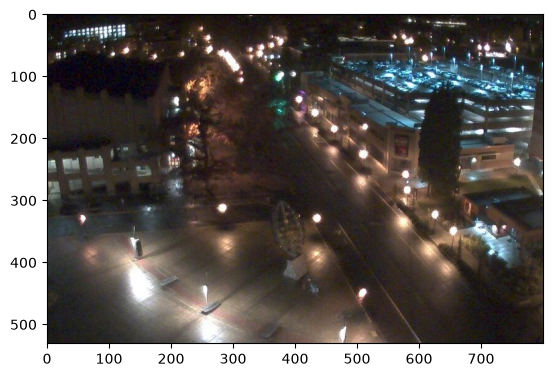

In [9]:
random_img_viz(train_img)

## Langkah 3: Pra pengolahan data

In [10]:
def standarized_input(image):

    std_img = cv2.resize(image, (1100,600))

    return std_img

In [11]:
def label_encoder(label):

    num_val = 0

    if(label == 'day'):
        num_val = 1
    
    return num_val

In [12]:
def preprocess(img_list):
    std_img_list = []

    for item in img_list:
        image = item[0]
        label = item[1]

        std_img = standarized_input(image)

        img_label = label_encoder(label)

        std_img_list.append((std_img, img_label))
    
    return std_img_list

In [13]:
train_std_img_list = preprocess(train_img)

In [14]:
pick_random = np.random.randint(0, len(train_std_img_list))

print(f'Image {pick_random}')
print(train_std_img_list[pick_random][0].shape)

Image 15
(600, 1100, 3)


Shape	: (600, 1100, 3)
Label	: 1


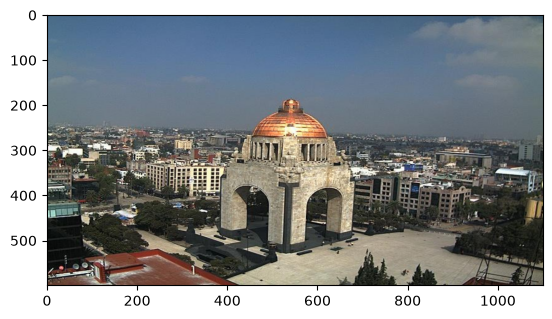

In [15]:
random_img_viz(train_std_img_list)

## Langkah 4: Ekstraksi rata rata kecerahan

In [16]:
def avg_brightness(image):

    img_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    sum_brightness = np.sum(img_hsv[:,:,2])
    area = image.shape[0] * image.shape[1]
    avg = sum_brightness / area

    return avg

Image 118
Avg Brighness: 170.9848


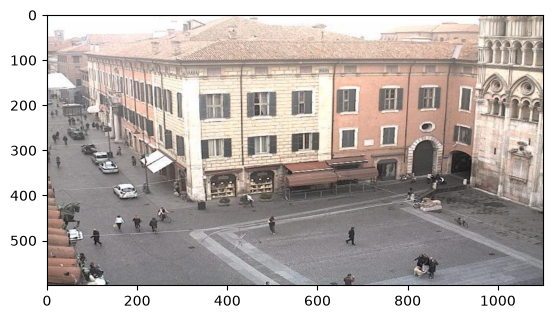

In [17]:
rand_img = np.random.randint(0, len(train_std_img_list))

feature_img = train_std_img_list[rand_img][0]

avg_img = avg_brightness(feature_img)

print(f'Image {rand_img}')
print(f'Avg Brighness: {avg_img:.4f}')
plt.imshow(feature_img)

## Langkah 5: Klasifikasi dengan threshold

In [18]:
def predict_label(img, threshold):

    avg = avg_brightness(img)
    pred = 0

    if avg > threshold:
        pred = 1
    
    return pred

Image 75
Actual label: 1
Predicted label: 1


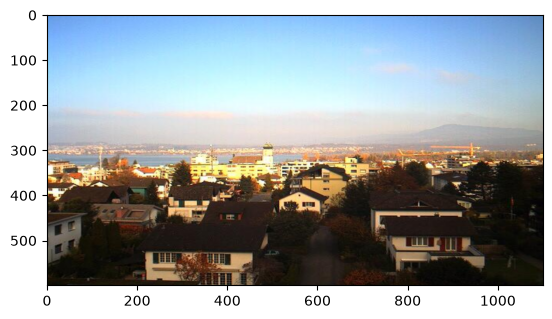

In [19]:
rand_img = np.random.randint(0, len(train_std_img_list))

pred = predict_label(train_std_img_list[rand_img][0], threshold=120)

print(f'Image {rand_img}')
print(f'Actual label: {train_std_img_list[rand_img][1]}')
print(f'Predicted label: {pred}')
plt.imshow(train_std_img_list[rand_img][0])

## Langkah 6: Evaluasi manual pada data latih

In [20]:
def evaluate(img_list, threshold):
    miss_labels = []

    for file in img_list:

        img = file[0]
        label = file[1]

        pred_label = predict_label(img, threshold)

        if pred_label != label:
            miss_labels.append((img, pred_label, label))
    
    total_img = len(img_list)
    corr_pred = total_img - len(miss_labels)
    accuracy = corr_pred / total_img

    print(f'Accuracy: {accuracy:.4f}')

In [21]:
evaluate(train_std_img_list, threshold=120)

Accuracy: 0.8417


## Evaluasi manual pada data uji

In [22]:
test_img = load_dataset(test_dir)

test_std_img_list = preprocess(test_img)

evaluate(test_std_img_list, threshold=120)

Accuracy: 0.8688


## Langkah 4 alternatif: Membuat feature vector

In [23]:
def extract_avg_bright_feature(img_list):
    avg_list = []
    labels = []

    for img in img_list:
        img_avg = avg_brightness(img[0])
        img_label = img[1]

        avg_list.append(img_avg)
        labels.append(img_label)

    data = np.column_stack((avg_list, labels))

    df = pd.DataFrame(data, columns=['AVG_BRIGHT', 'LABELS'])

    return df

In [24]:
train_avg_img = extract_avg_bright_feature(train_std_img_list)
print(f'Shape: {train_avg_img.shape}')
train_avg_img.head()

Shape: (240, 2)


,AVG_BRIGHT,LABELS
0,175.092992,1.0
1,192.907867,1.0
2,132.133823,1.0
3,199.749191,1.0
4,109.947203,1.0


In [25]:
test_avg_img = extract_avg_bright_feature(test_std_img_list)
print(f'Shape: {test_avg_img.shape}')
test_avg_img.head()

Shape: (160, 2)


,AVG_BRIGHT,LABELS
0,194.228062,1.0
1,157.826662,1.0
2,201.607444,1.0
3,191.237441,1.0
4,188.119652,1.0


## Langkah 5 alternatif: Membuat model SVM

In [26]:
from sklearn.svm import SVC

X_train = train_avg_img.iloc[:,0].values.reshape(-1,1)
y_train = train_avg_img.iloc[:,1]
X_test = test_avg_img.iloc[:,0].values.reshape(-1,1)
y_test = test_avg_img.iloc[:,1]

model = SVC()
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Langkah 6 alternatif: Evaluasi SVM

In [27]:
from sklearn.metrics import accuracy_score

y_train_pred = model.predict(X_train)

acc_train = accuracy_score(y_train, y_train_pred)

y_test_pred = model.predict(X_test)

acc_test = accuracy_score(y_test, y_test_pred)

print(f'Accuracy on train: {acc_train}')
print(f'Accuracy on test: {acc_test}')

Accuracy on train: 0.8583333333333333
Accuracy on test: 0.9
